In [1]:
!pip install opencv-python-headless
!pip install opencv-python
!pip install opencv-contrib-python

import cv2
import numpy as np
import os
import time
from concurrent.futures import ThreadPoolExecutor
from google.colab import files

image_dir = "/content/images"
os.makedirs(image_dir, exist_ok=True)

uploaded = files.upload()

for name, data in uploaded.items():
    with open(os.path.join(image_dir, name), 'wb') as f:
        f.write(data)

def apply_filters_cpu(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None, None
    blurred = cv2.GaussianBlur(image, (15, 15), 0)
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened = cv2.filter2D(image, -1, sharpen_kernel)
    return blurred, sharpened

def process_images_cpu(image_paths):
    start_time = time.time()
    results = []
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(apply_filters_cpu, img) for img in image_paths]
        results = [future.result() for future in futures]
    end_time = time.time()
    return results, end_time - start_time

image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith(('.png', '.jpg', '.jpeg'))]
if not image_paths:
    raise FileNotFoundError(f"No images found in the directory '{image_dir}'.")

cpu_results, cpu_time = process_images_cpu(image_paths)
print(f"CPU processing time: {cpu_time:.2f} seconds")

output_dir = "/content/output_cpu"
os.makedirs(output_dir, exist_ok=True)
for i, (blurred, sharpened) in enumerate(cpu_results):
    if blurred is not None and sharpened is not None:
        cv2.imwrite(os.path.join(output_dir, f"image_{i+1}_blurred.jpg"), blurred)
        cv2.imwrite(os.path.join(output_dir, f"image_{i+1}_sharpened.jpg"), sharpened)

Saving git.jpeg to git.jpeg
Saving new.jpg to new.jpg
Saving newimage.png to newimage.png
CPU processing time: 0.08 seconds


Saving git.jpeg to git.jpeg
Saving new.jpg to new.jpg
Saving newimage.png to newimage.png


GPU processing time: 0.5593 seconds


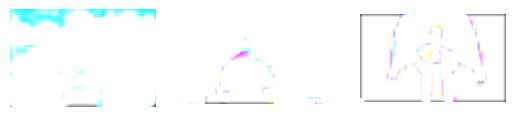

In [1]:
import cv2
import torch
import time
from matplotlib import pyplot as plt
from google.colab import files
import os

uploaded = files.upload()

image_dir = "/content/images"
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

for name, data in uploaded.items():
    with open(os.path.join(image_dir, name), 'wb') as f:
        f.write(data)

def apply_filter_gpu(image, filter_type):
    image_tensor = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_tensor = image_tensor.unsqueeze(0).to(device)

    if filter_type == "blur":
        kernel = torch.ones(1, 1, 15, 15).to(device) / 225.0
        kernel = kernel.repeat(3, 1, 1, 1)
        blurred = torch.nn.functional.conv2d(image_tensor, kernel, padding=7, groups=3)
        return blurred.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    elif filter_type == "sharpen":
        kernel = torch.tensor([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        sharpened = torch.nn.functional.conv2d(image_tensor, kernel, padding=1, groups=3)
        return sharpened.squeeze().permute(1, 2, 0).cpu().numpy() * 255

def process_images_gpu(image_paths):
    results = []
    start_time = time.time()
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            continue
        results.append(apply_filter_gpu(image, "blur"))
    end_time = time.time()
    print(f"GPU processing time: {end_time - start_time:.4f} seconds")
    return results

image_paths = [os.path.join(image_dir, name) for name in uploaded.keys()]
gpu_results = process_images_gpu(image_paths)

for i, img in enumerate(gpu_results):
    plt.subplot(1, len(gpu_results), i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
plt.show()
